# Classical Lane Line Detection

This notebook shows a classical computer-vision pipeline for lane-line detection on road.

## Scope and Methodology


In [1]:
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.figsize": (12, 6)})
plt.rcParams["image.cmap"] = "gray"

SAMPLE_IMAGE_PATH = Path("test_images/solidWhiteRight.jpg")
SAMPLE_IMAGE = mpimg.imread(SAMPLE_IMAGE_PATH)

if SAMPLE_IMAGE.ndim == 2:
    SAMPLE_IMAGE = np.repeat(SAMPLE_IMAGE[..., None], 3, axis=2)
elif SAMPLE_IMAGE.shape[2] == 4:
    SAMPLE_IMAGE = SAMPLE_IMAGE[:, :, :3]

if SAMPLE_IMAGE.dtype.kind == "f" and SAMPLE_IMAGE.max() <= 1.0:
    SAMPLE_IMAGE = (SAMPLE_IMAGE * 255).astype(np.uint8)
else:
    SAMPLE_IMAGE = SAMPLE_IMAGE.astype(np.uint8)


# Global parameters

# Gaussian smoothing
KERNEL_SIZE = 5

# Canny Edge Detector
LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150

# Region-of-interest vertices
# We want a trapezoid shape, with bottom edge at the bottom of the image
TRAP_BOTTOM_WIDTH = 0.85  # width of bottom edge of trapezoid, expressed as percentage of image width
TRAP_TOP_WIDTH = 0.08  # ditto for top edge of trapezoid
TRAP_HEIGHT = 0.4  # height of the trapezoid expressed as percentage of image height

# Hough Transform
HOUGH_RHO = 2 # distance resolution in pixels of the Hough grid
HOUGH_THETA = 1 * np.pi/180 # angular resolution in radians of the Hough grid
HOUGH_THRESHOLD = 15	 # minimum number of votes (intersections in Hough grid cell)
HOUGH_MIN_LINE_LENGTH = 20 #minimum number of pixels making up a line
HOUGH_MAX_LINE_GAP = 20	# maximum gap in pixels between connectable line segments

print(f"Sample image loaded: {SAMPLE_IMAGE.shape}, dtype={SAMPLE_IMAGE.dtype}")

Sample image loaded: (540, 960, 3), dtype=uint8


## Stage 1. Grayscale Conversion

The RGB input is reduced to a luminance channel using the standard luminosity model. This preserves perceptual brightness while removing chromatic variation that is not required for lane localization.

In [2]:
def grayscale(image):
    array = np.asarray(image)

    if array.ndim == 2:
        return array.astype(np.float64)

    rgb = array[..., :3].astype(np.float64)
    return 0.2126 * rgb[..., 0] + 0.7152 * rgb[..., 1] + 0.0722 * rgb[..., 2]

## Input Image

The reference image establishes the visual conditions used throughout the notebook. All subsequent stages operate on this same sample scene so that the effect of each algorithm can be assessed independently.

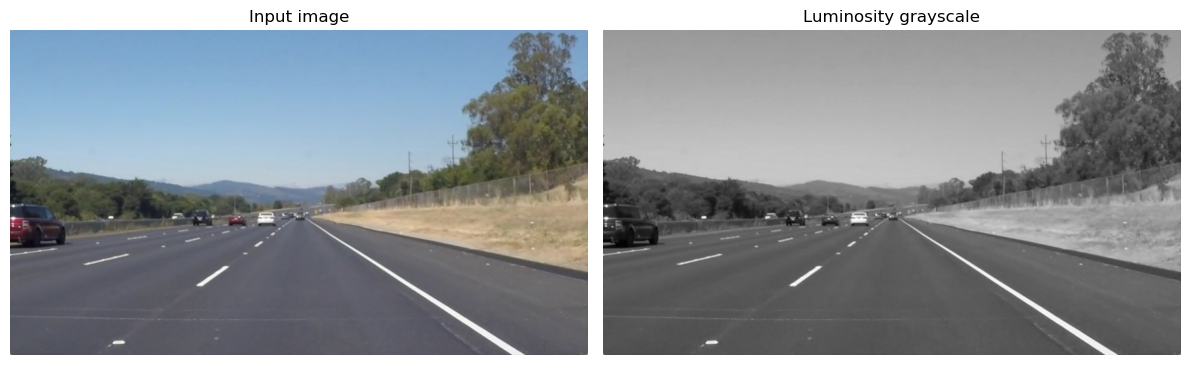

In [3]:
gray_sample = grayscale(SAMPLE_IMAGE)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(SAMPLE_IMAGE)
axes[0].set_title("Input image")
axes[0].axis("off")
axes[1].imshow(gray_sample, cmap="gray")
axes[1].set_title("Luminosity grayscale")
axes[1].axis("off")
plt.tight_layout()

## Stage 2. Color Filtering

A simple channel-thresholding strategy suppresses most of the background texture while retaining bright white markings and yellow lane paint. The filter is intentionally explicit for instructional clarity.

In [4]:
def filter_colors(image):
    array = np.asarray(image).astype(np.uint8)
    rgb = array[..., :3]

    white_mask = (
        (rgb[..., 0] >= 200)
        & (rgb[..., 1] >= 200)
        & (rgb[..., 2] >= 200)
    )

    yellow_mask = (
        (rgb[..., 0] >= 160)
        & (rgb[..., 1] >= 140)
        & (rgb[..., 2] <= 140)
        & (rgb[..., 0] >= rgb[..., 1])
        & (rgb[..., 1] >= rgb[..., 2])
    )

    filtered = np.zeros_like(rgb)
    selected = white_mask | yellow_mask
    filtered[selected] = rgb[selected]
    return filtered

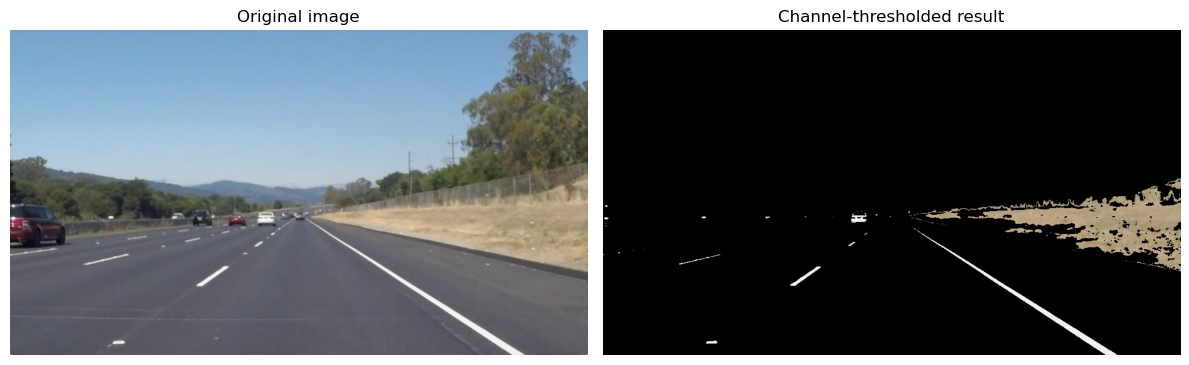

In [5]:
filtered_sample = filter_colors(SAMPLE_IMAGE)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(SAMPLE_IMAGE)
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(filtered_sample)
axes[1].set_title("Channel-thresholded result")
axes[1].axis("off")
plt.tight_layout()

## Stage 3. Gaussian Blur
This step smooths the image to reduce high-frequency noise, ensuring that subsequent algorithms (like edge detection) do not falsely identify noise as edges.

1. **Kernel Generation:** Mathematically computes a normalized 2D Gaussian matrix based on a specified size and standard deviation ($\sigma$).
2. **Manual Convolution:** Iteratively applies the kernel across the padded image matrix to blur the image, supporting both grayscale and color inputs.

In [6]:
def gaussian_blur(image, kernel_size=5, sigma=None):
    array = np.asarray(image).astype(np.float64)

    if kernel_size % 2 == 0:
        kernel_size += 1

    if sigma is None:
        sigma = kernel_size / 6.0

    radius = kernel_size // 2
    coords = np.arange(-radius, radius + 1, dtype=np.float64)
    xx, yy = np.meshgrid(coords, coords)
    kernel = np.exp(-(xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
    kernel /= kernel.sum()

    if array.ndim == 2:
        padded = np.pad(array, radius, mode="reflect")
        blurred = np.zeros_like(array)
        for row in range(array.shape[0]):
            for col in range(array.shape[1]):
                patch = padded[row:row + kernel_size, col:col + kernel_size]
                blurred[row, col] = np.sum(patch * kernel)
        return blurred

    blurred_channels = []
    for channel in range(array.shape[2]):
        padded = np.pad(array[..., channel], radius, mode="reflect")
        blurred_channel = np.zeros(array.shape[:2], dtype=np.float64)
        for row in range(array.shape[0]):
            for col in range(array.shape[1]):
                patch = padded[row:row + kernel_size, col:col + kernel_size]
                blurred_channel[row, col] = np.sum(patch * kernel)
        blurred_channels.append(blurred_channel)

    return np.stack(blurred_channels, axis=-1)

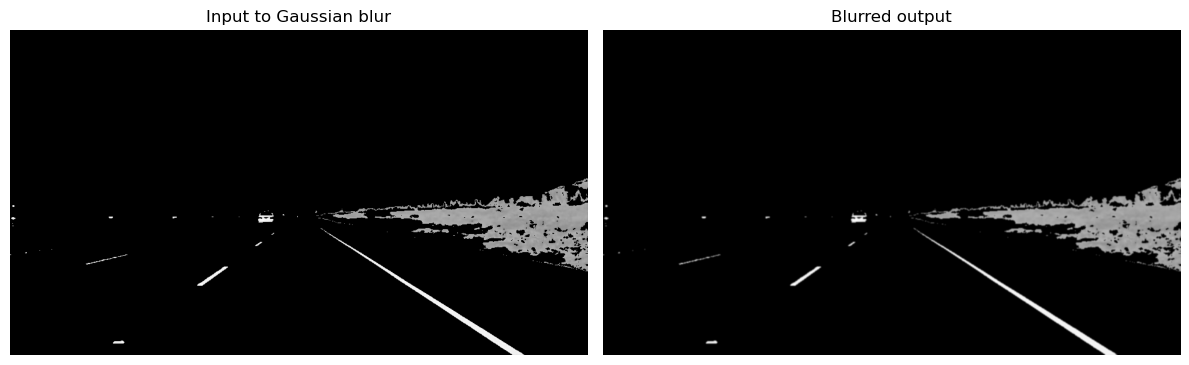

In [7]:
blur_input = grayscale(filtered_sample)
blur_sample = gaussian_blur(blur_input, kernel_size=KERNEL_SIZE)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(blur_input, cmap="gray")
axes[0].set_title("Input to Gaussian blur")
axes[0].axis("off")
axes[1].imshow(blur_sample, cmap="gray")
axes[1].set_title("Blurred output")
axes[1].axis("off")
plt.tight_layout()

## Stage 4. Canny Edge Detection

The edge detector is implemented manually to expose every intermediate step used in classical lane detection: Sobel gradients, gradient magnitude and direction, non-maximum suppression, and hysteresis thresholding. This makes the pipeline suitable for technical explanation and assessment.

In [8]:
def canny(image, low_threshold=LOW_THRESHOLD, high_threshold=HIGH_THRESHOLD):
    array = np.asarray(image).astype(np.float64)

    if array.ndim != 2:
        raise ValueError("canny expects a single-channel grayscale image")

    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ], dtype=np.float64)
    sobel_y = np.array([
        [1, 2, 1],
        [0, 0, 0],
        [-1, -2, -1],
    ], dtype=np.float64)

    padded = np.pad(array, 1, mode="reflect")
    gradient_x = np.zeros_like(array)
    gradient_y = np.zeros_like(array)

    for row in range(array.shape[0]):
        for col in range(array.shape[1]):
            patch = padded[row:row + 3, col:col + 3]
            gradient_x[row, col] = np.sum(patch * sobel_x)
            gradient_y[row, col] = np.sum(patch * sobel_y)

    magnitude = np.hypot(gradient_x, gradient_y)
    direction = np.degrees(np.arctan2(gradient_y, gradient_x))
    direction = (direction + 180.0) % 180.0

    suppressed = np.zeros_like(magnitude)
    for row in range(1, array.shape[0] - 1):
        for col in range(1, array.shape[1] - 1):
            angle = direction[row, col]
            current = magnitude[row, col]

            if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
                neighbors = (magnitude[row, col - 1], magnitude[row, col + 1])
            elif 22.5 <= angle < 67.5:
                neighbors = (magnitude[row - 1, col + 1], magnitude[row + 1, col - 1])
            elif 67.5 <= angle < 112.5:
                neighbors = (magnitude[row - 1, col], magnitude[row + 1, col])
            else:
                neighbors = (magnitude[row - 1, col - 1], magnitude[row + 1, col + 1])

            if current >= neighbors[0] and current >= neighbors[1]:
                suppressed[row, col] = current

    strong_value = 255
    weak_value = 75
    result = np.zeros_like(suppressed, dtype=np.uint8)
    strong_rows, strong_cols = np.where(suppressed >= high_threshold)
    weak_rows, weak_cols = np.where((suppressed >= low_threshold) & (suppressed < high_threshold))

    result[strong_rows, strong_cols] = strong_value
    result[weak_rows, weak_cols] = weak_value

    stack = list(zip(strong_rows.tolist(), strong_cols.tolist()))
    while stack:
        row, col = stack.pop()
        for delta_row in (-1, 0, 1):
            for delta_col in (-1, 0, 1):
                if delta_row == 0 and delta_col == 0:
                    continue
                neighbor_row = row + delta_row
                neighbor_col = col + delta_col
                if 0 <= neighbor_row < result.shape[0] and 0 <= neighbor_col < result.shape[1]:
                    if result[neighbor_row, neighbor_col] == weak_value:
                        result[neighbor_row, neighbor_col] = strong_value
                        stack.append((neighbor_row, neighbor_col))

    result[result != strong_value] = 0
    return result

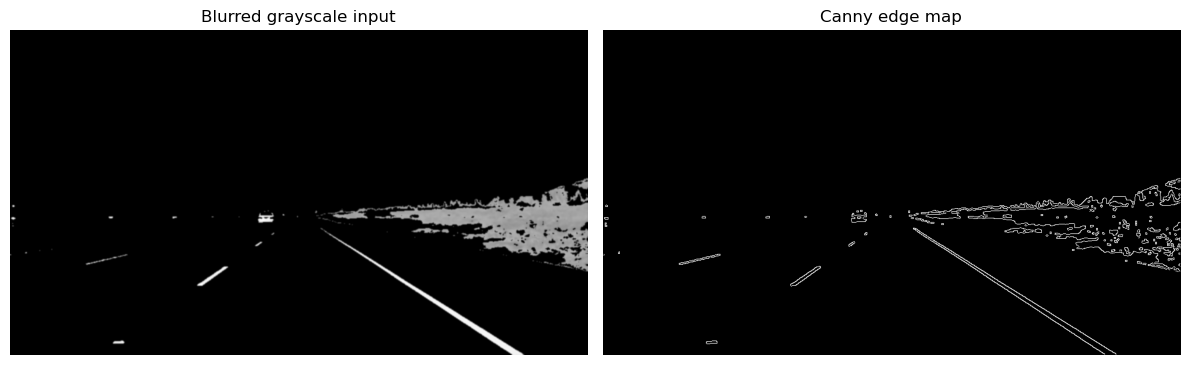

In [9]:
edge_sample = canny(blur_sample, LOW_THRESHOLD, HIGH_THRESHOLD)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(blur_sample, cmap="gray")
axes[0].set_title("Blurred grayscale input")
axes[0].axis("off")
axes[1].imshow(edge_sample, cmap="gray")
axes[1].set_title("Canny edge map")
axes[1].axis("off")
plt.tight_layout()

## Stage 5. Region of Interest

The road search is constrained to a trapezoidal region covering the lower half of the image. This reduces interference from the sky, roadside vegetation, and distant vehicles.

In [10]:
def region_of_interest(image, vertices):
    array = np.asarray(image)
    polygon = np.asarray(vertices, dtype=np.float64).reshape(-1, 2)

    masked = np.zeros_like(array)

    min_x = max(int(np.floor(np.min(polygon[:, 0]))), 0)
    max_x = min(int(np.ceil(np.max(polygon[:, 0]))), array.shape[1] - 1)
    min_y = max(int(np.floor(np.min(polygon[:, 1]))), 0)
    max_y = min(int(np.ceil(np.max(polygon[:, 1]))), array.shape[0] - 1)

    for row in range(min_y, max_y + 1):
        for col in range(min_x, max_x + 1):
            inside = False
            j = len(polygon) - 1
            for i in range(len(polygon)):
                xi, yi = polygon[i]
                xj, yj = polygon[j]
                intersects = ((yi > row) != (yj > row)) and (
                    col < (xj - xi) * (row - yi) / ((yj - yi) if (yj - yi) != 0 else 1e-9) + xi
                )
                if intersects:
                    inside = not inside
                j = i

            if inside:
                if array.ndim == 2:
                    masked[row, col] = array[row, col]
                else:
                    masked[row, col, :] = array[row, col, :]

    return masked

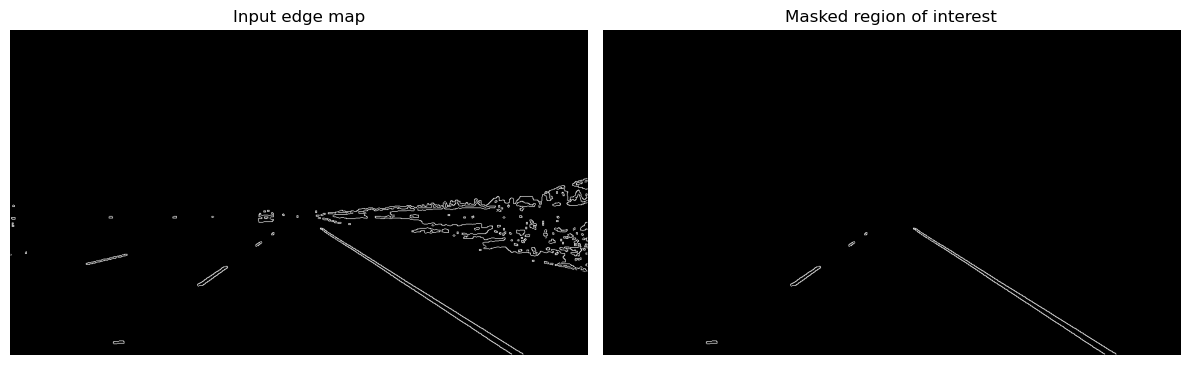

In [11]:
imshape = edge_sample.shape
vertices = np.array([
    [
        ((imshape[1] * (1 - TRAP_BOTTOM_WIDTH)) / 2, imshape[0]),
        ((imshape[1] * (1 - TRAP_TOP_WIDTH)) / 2, imshape[0] * (1 - TRAP_HEIGHT)),
        (imshape[1] - (imshape[1] * (1 - TRAP_TOP_WIDTH)) / 2, imshape[0] * (1 - TRAP_HEIGHT)),
        (imshape[1] - (imshape[1] * (1 - TRAP_BOTTOM_WIDTH)) / 2, imshape[0]),
    ]
], dtype=np.int32)
roi_sample = region_of_interest(edge_sample, vertices)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(edge_sample, cmap="gray")
axes[0].set_title("Input edge map")
axes[0].axis("off")
axes[1].imshow(roi_sample, cmap="gray")
axes[1].set_title("Masked region of interest")
axes[1].axis("off")
plt.tight_layout()

## Stage 6. Hough Transform

The masked edge map is converted into line hypotheses through explicit accumulator voting in Hough space. Peaks in the accumulator are then translated into candidate line segments.

In [12]:
def hough_lines(image, rho=HOUGH_RHO, theta=HOUGH_THETA, threshold=HOUGH_THRESHOLD, min_line_len=HOUGH_MIN_LINE_LENGTH, max_line_gap=HOUGH_MAX_LINE_GAP):
    edge_map = np.asarray(image)
    if edge_map.ndim != 2:
        raise ValueError("hough_lines expects a single-channel edge map")

    height, width = edge_map.shape
    ys, xs = np.nonzero(edge_map)
    if len(xs) == 0:
        return np.empty((0, 1, 4), dtype=np.int32)

    rho_max = int(np.ceil(np.hypot(height, width)))
    rho_values = np.arange(-rho_max, rho_max + rho, rho)
    theta_values = np.arange(-np.pi / 2, np.pi / 2, theta)
    accumulator = np.zeros((len(rho_values), len(theta_values)), dtype=np.int32)

    cos_values = np.cos(theta_values)
    sin_values = np.sin(theta_values)

    for x, y in zip(xs, ys):
        rho_projection = x * cos_values + y * sin_values
        rho_indices = np.round((rho_projection + rho_max) / rho).astype(int)
        valid = (rho_indices >= 0) & (rho_indices < len(rho_values))
        accumulator[rho_indices[valid], np.arange(len(theta_values))[valid]] += 1

    peaks = []
    for rho_index in range(1, accumulator.shape[0] - 1):
        for theta_index in range(1, accumulator.shape[1] - 1):
            vote = accumulator[rho_index, theta_index]
            if vote < threshold:
                continue
            neighborhood = accumulator[rho_index - 1:rho_index + 2, theta_index - 1:theta_index + 2]
            if vote == np.max(neighborhood):
                peaks.append((rho_values[rho_index], theta_values[theta_index], vote))

    segments = []
    for rho_value, theta_value, _ in peaks:
        cos_theta = np.cos(theta_value)
        sin_theta = np.sin(theta_value)
        direction = np.array([-sin_theta, cos_theta], dtype=np.float64)

        distances = np.abs(xs * cos_theta + ys * sin_theta - rho_value)
        support = distances <= rho / 2.0
        if not np.any(support):
            continue

        support_x = xs[support].astype(np.float64)
        support_y = ys[support].astype(np.float64)
        projections = support_x * direction[0] + support_y * direction[1]

        order = np.argsort(projections)
        support_x = support_x[order]
        support_y = support_y[order]
        projections = projections[order]

        start_index = 0
        while start_index < len(projections):
            end_index = start_index
            while (
                end_index + 1 < len(projections)
                and projections[end_index + 1] - projections[end_index] <= max_line_gap
            ):
                end_index += 1

            if end_index > start_index:
                segment_length = projections[end_index] - projections[start_index]
                if segment_length >= min_line_len:
                    x1 = int(round(support_x[start_index]))
                    y1 = int(round(support_y[start_index]))
                    x2 = int(round(support_x[end_index]))
                    y2 = int(round(support_y[end_index]))
                    segments.append([[x1, y1, x2, y2]])

            start_index = end_index + 1

    if len(segments) == 0:
        return np.empty((0, 1, 4), dtype=np.int32)
    return np.array(segments, dtype=np.int32)

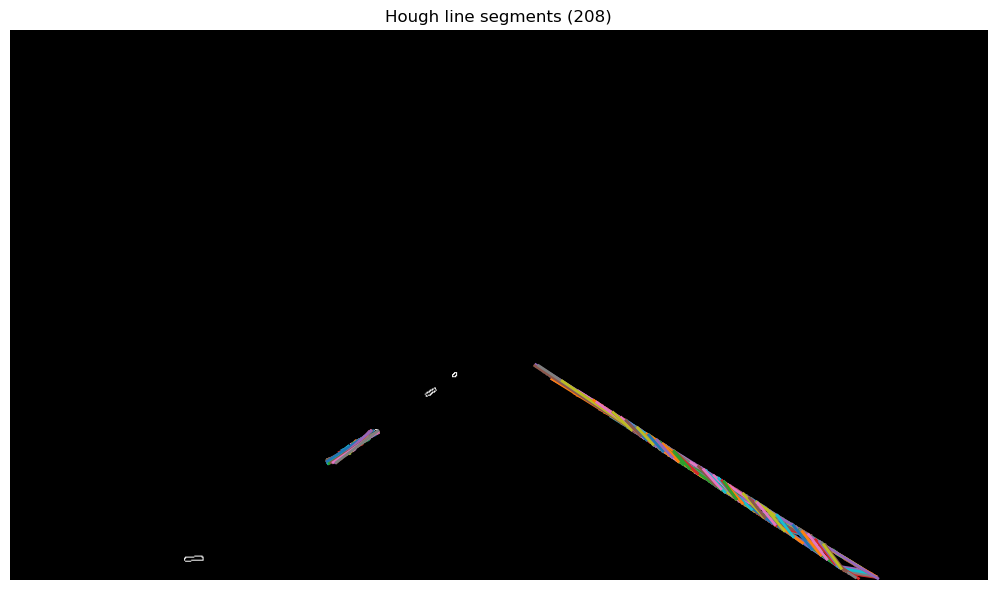

In [13]:
hough_segments = hough_lines(roi_sample)

fig, ax = plt.subplots(1, 1)
ax.imshow(roi_sample, cmap="gray")
for segment in hough_segments:
    x1, y1, x2, y2 = segment[0]
    ax.plot([x1, x2], [y1, y2], linewidth=2)
ax.set_title(f"Hough line segments ({len(hough_segments)})")
ax.axis("off")
plt.tight_layout()

## Stage 7. Lane Reconstruction

The detected segments are grouped by orientation and extrapolated into full lane boundaries. A manual rasterization routine is then used to draw the reconstructed lines on a blank canvas.

## Integrated Pipeline

The final annotation stage combines preprocessing, edge detection, masking, Hough voting, and lane rendering into a single reproducible function suitable for image-level evaluation.

In [14]:
def draw_lines(image, lines, color=(255, 0, 0), thickness=6):
    canvas = np.asarray(image)
    if canvas.ndim != 3 or canvas.shape[2] < 3:
        raise ValueError("draw_lines expects a 3-channel color canvas")

    if lines is None or len(lines) == 0:
        return canvas

    def bresenham_line(x0, y0, x1, y1):
        points = []
        dx = abs(x1 - x0)
        dy = -abs(y1 - y0)
        step_x = 1 if x0 < x1 else -1
        step_y = 1 if y0 < y1 else -1
        error = dx + dy
        x, y = x0, y0
        while True:
            points.append((x, y))
            if x == x1 and y == y1:
                break
            double_error = 2 * error
            if double_error >= dy:
                error += dy
                x += step_x
            if double_error <= dx:
                error += dx
                y += step_y
        return points

    slopes = []
    left_points = []
    right_points = []
    center_x = canvas.shape[1] / 2.0

    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 == x1:
            continue
        slope = (y2 - y1) / (x2 - x1)
        if abs(slope) < 0.5:
            continue
        if slope < 0 and x1 < center_x and x2 < center_x:
            left_points.extend([(x1, y1), (x2, y2)])
            slopes.append(slope)
        elif slope > 0 and x1 > center_x and x2 > center_x:
            right_points.extend([(x1, y1), (x2, y2)])
            slopes.append(slope)

    def fit_lane(points):
        if len(points) < 2:
            return None
        xs = np.array([point[0] for point in points], dtype=np.float64)
        ys = np.array([point[1] for point in points], dtype=np.float64)
        slope, intercept = np.polyfit(xs, ys, 1)
        y_bottom = canvas.shape[0] - 1
        y_top = int(canvas.shape[0] * (1 - TRAP_HEIGHT))
        x_bottom = int(round((y_bottom - intercept) / slope))
        x_top = int(round((y_top - intercept) / slope))
        return x_bottom, y_bottom, x_top, y_top

    for lane_points in (left_points, right_points):
        fitted = fit_lane(lane_points)
        if fitted is None:
            continue
        x_bottom, y_bottom, x_top, y_top = fitted
        for x, y in bresenham_line(x_bottom, y_bottom, x_top, y_top):
            for row in range(max(0, y - thickness // 2), min(canvas.shape[0], y + thickness // 2 + 1)):
                for col in range(max(0, x - thickness // 2), min(canvas.shape[1], x + thickness // 2 + 1)):
                    canvas[row, col] = color

    return canvas

In [15]:
print(f"Detected Hough segments in the reference mask: {len(hough_segments)}")

Detected Hough segments in the reference mask: 208


## Final Result


In [16]:
def annotate_image(image, steps=None):
    rgb = np.asarray(image).astype(np.uint8)

    pipeline = {
        "color_filter": True,
        "blur": True,
        "canny": True,
        "roi": True,
        "hough": True,
        "overlay": True,
    }
    if steps:
        for key, value in steps.items():
            if key in pipeline:
                pipeline[key] = bool(value)

    filtered = filter_colors(rgb) if pipeline["color_filter"] else rgb
    gray = grayscale(filtered)
    blurred = gaussian_blur(gray, kernel_size=KERNEL_SIZE) if pipeline["blur"] else gray
    edges = canny(blurred, LOW_THRESHOLD, HIGH_THRESHOLD) if pipeline["canny"] else np.asarray(blurred).astype(np.uint8)

    height, width = gray.shape
    vertices = np.array([
        [
            ((width * (1 - TRAP_BOTTOM_WIDTH)) / 2, height),
            ((width * (1 - TRAP_TOP_WIDTH)) / 2, height * (1 - TRAP_HEIGHT)),
            (width - (width * (1 - TRAP_TOP_WIDTH)) / 2, height * (1 - TRAP_HEIGHT)),
            (width - (width * (1 - TRAP_BOTTOM_WIDTH)) / 2, height),
        ]
    ], dtype=np.int32)

    masked_edges = region_of_interest(edges, vertices) if pipeline["roi"] else edges
    segments = hough_lines(masked_edges) if pipeline["hough"] else np.empty((0, 1, 4), dtype=np.int32)

    lane_canvas = np.zeros((height, width, 3), dtype=np.uint8)
    lane_canvas = draw_lines(lane_canvas, segments)

    if not pipeline["overlay"]:
        return lane_canvas

    alpha = 0.8
    beta = 1.0
    gamma = 0.0
    base = rgb.astype(np.float64)
    overlay = lane_canvas.astype(np.float64)
    annotated = np.clip(base * alpha + overlay * beta + gamma, 0, 255).astype(np.uint8)
    return annotated

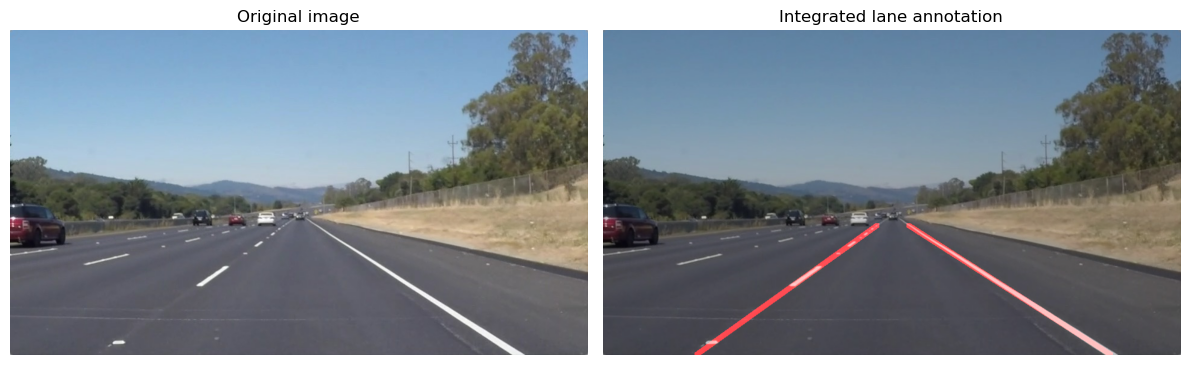

In [17]:
annotated_sample = annotate_image(SAMPLE_IMAGE)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(SAMPLE_IMAGE)
axes[0].set_title("Original image")
axes[0].axis("off")
axes[1].imshow(annotated_sample)
axes[1].set_title("Integrated lane annotation")
axes[1].axis("off")
plt.tight_layout()

In [ ]:
import os
import shutil
import subprocess
from typing import Any

FFMPEG_EXE = os.environ.get("IMAGEIO_FFMPEG_EXE") or shutil.which("ffmpeg")
if not FFMPEG_EXE:
    raise FileNotFoundError("FFmpeg not found on PATH. Install FFmpeg or set IMAGEIO_FFMPEG_EXE.")
os.environ["IMAGEIO_FFMPEG_EXE"] = FFMPEG_EXE

try:
    from moviepy.video.io.VideoFileClip import VideoFileClip
except Exception:
    VideoFileClip = None


def _ffmpeg_has_nvenc(ffmpeg_exe: str) -> bool:
    try:
        result = subprocess.run(
            [ffmpeg_exe, "-hide_banner", "-encoders"],
            check=True,
            capture_output=True,
            text=True,
        )
    except Exception:
        return False

    output = (result.stdout or "") + (result.stderr or "")
    return ("h264_nvenc" in output) or ("hevc_nvenc" in output) or ("av1_nvenc" in output)


def annotate_image_array(frame, steps=None):
    """Convert a MoviePy frame to a NumPy image and run the lane pipeline."""
    arr = np.asarray(frame)
    if arr.dtype.kind == "f":
        if arr.max() <= 1.0:
            arr = arr * 255.0
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    elif arr.dtype != np.uint8:
        arr = arr.astype(np.uint8)
    return annotate_image(arr, steps=steps)


def _make_annotated_clip(video, steps=None):
    frame_transform = getattr(video, "image_transform", None)
    frame_fn = lambda frame: annotate_image_array(frame, steps=steps)

    if frame_transform is not None:
        return frame_transform(frame_fn)

    frame_transform = getattr(video, "fl_image", None)
    if frame_transform is None:
        raise AttributeError(
            "Your MoviePy version does not support frame transforms. "
            "Expected 'image_transform' or 'fl_image'."
        )
    return frame_transform(frame_fn)


def annotate_video(
    input_file: str,
    output_file: str,
    *,
    steps=None,
    show_progress: bool = True,
    use_gpu: bool = False,
    threads: int | None = None,
    codec: str | None = None,
    preset: str = "ultrafast",
    scale: float = 1.0,
    fps: int | None = None,
    subclip: tuple | None = None,
):
    """Annotate a video by applying `annotate_image()` to each frame."""
    if VideoFileClip is None:
        raise ImportError("MoviePy is required. Install it with: pip install moviepy")

    video: Any = VideoFileClip(input_file, audio=False)

    if subclip is not None:
        start, end = subclip
        trim_fn = getattr(video, "with_section_trimmed", None) or getattr(video, "subclip", None)
        if callable(trim_fn):
            video = trim_fn(start, end)
        else:
            print("Warning: trimming not supported, processing full video.")

    if scale != 1.0:
        resize_fn = getattr(video, "resized", None) or getattr(video, "resize", None)
        if callable(resize_fn):
            video = resize_fn(scale)
        else:
            print("Warning: resizing not supported, processing full video.")

    annotated_video: Any = None
    effective_threads = threads if threads is not None else max(1, os.cpu_count() or 1)

    nvenc_available = _ffmpeg_has_nvenc(os.environ["IMAGEIO_FFMPEG_EXE"])
    if use_gpu and not nvenc_available:
        print("NVENC not available; using CPU encoding.")
        use_gpu = False

    target_codec = codec or ("h264_nvenc" if use_gpu else "libx264")
    logger = "bar" if show_progress else None
    base_fps = getattr(video, "fps", None)
    output_fps = fps if fps is not None else base_fps

    try:
        annotated_video = _make_annotated_clip(video, steps=steps)
        write_kwargs = {
            "audio": False,
            "codec": target_codec,
            "preset": preset,
            "threads": effective_threads,
            "logger": logger,
            "ffmpeg_params": ["-pix_fmt", "yuv420p"],
        }
        if output_fps is not None:
            write_kwargs["fps"] = output_fps

        try:
            annotated_video.write_videofile(output_file, **write_kwargs)
        except Exception:
            if use_gpu and target_codec == "h264_nvenc":
                print("GPU encoder unavailable; falling back to CPU encoding.")
                write_kwargs["codec"] = "libx264"
                annotated_video = _make_annotated_clip(video, steps=steps)
                annotated_video.write_videofile(output_file, **write_kwargs)
            else:
                raise
    finally:
        if annotated_video is not None:
            annotated_video.close()
        video.close()


output_file = "challenge_fast_output.mp4"
annotate_video(
    "challenge.mp4",
    output_file,
    use_gpu=True,
    threads=max(1, os.cpu_count() or 1),
    preset="ultrafast",
    scale=0.5,
    fps=15,
)


                                                                      
                                                                       
frame_index:   1%|▏         | 2/150 [04:31<06:27,  2.62s/it, now=None] 

MoviePy - Building video challenge_fast_output.mp4.
MoviePy - Writing video challenge_fast_output.mp4



GPU encoder unavailable; falling back to CPU encoding.


                                                                      
                                                                    

frame_index:   1%|▏         | 2/150 [04:43<06:27,  2.62s/it, now=None]
                                                                      
                                                                    

frame_index:   1%|▏         | 2/150 [04:43<06:27,  2.62s/it, now=None]


MoviePy - Building video challenge_fast_output.mp4.
MoviePy - Writing video challenge_fast_output.mp4



KeyboardInterrupt: 